In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from src.utils.config import EDA_OUTPUT_PARAMS_PATH, FE_OUTPUT_PARAMS_PATH, TRAINING_OUTPUT_PLOTS_PATH, FE_OUTPUT_MODELS_PATH
from src.data.processed_data import get_feature_engineered_data
from src.data.processed_data import get_validated_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
from src.visualization.plots import make_plot
from src.visualization.plots import multiple_scatterplot

In [3]:
featured_data = get_feature_engineered_data()
validated_data = get_validated_data()

with open(EDA_OUTPUT_PARAMS_PATH, "r", encoding="utf-8") as file:
    eda_output = json.load(file)
with open(FE_OUTPUT_PARAMS_PATH, 'r', encoding="utf-8") as file:
    fe_output = json.load(file)
validated_data

,appid,name,release_year,release_date,genres,categories,price,recommendations,developer,publisher
0,3057270,Seafarer's Gambit,2024,2024-07-05,Action;Adventure;Indie;RPG;Strategy,Single-player;Family Sharing,3.99,0,Bouncy Rocket Studios,Bouncy Rocket Studios
1,3822840,Capitalist Misadventures,2025,2025-07-25,Casual;Indie;Simulation;Strategy,Single-player;Save Anytime;Family Sharing,7.99,0,Caramelo Studios,Caramelo Studios
2,3216640,The Beast and the Princess,2025,2025-06-17,Adventure;Indie;Strategy,Single-player;Steam Achievements;Full controll...,12.99,0,Libragames,Libragames
3,2403620,Air Twister,2023,2023-11-10,Action;Adventure;Indie,Single-player;Steam Achievements;Full controll...,24.99,0,YS Net,ININ
4,1538040,Horde Slayer,2021,2021-03-19,Action;Adventure;Casual;Indie;RPG;Early Access,Single-player;Steam Achievements;Full controll...,3.99,0,Wagner Rodrigues,Wagner Rodrigues
...,...,...,...,...,...,...,...,...,...,...
63990,3097010,X Simulator Drone,2024,2024-07-31,Casual;Indie;Simulation,Single-player;Family Sharing,14.99,0,Inonia Games,Inonia Games
63991,3304930,Retro Dungeon Slayer,2025,2025-03-03,Action;Indie;Early Access,Single-player;Family Sharing,4.99,0,Hard Shark Games,Hard Shark Games
63992,1461580,Molecule Builder,2021,2021-02-04,Simulation;Education,Single-player;Tracked Controller Support;VR On...,14.99,0,Xennial Digital,Xennial Digital
63993,1379120,MechNest,2024,2024-04-13,Action;Indie,Single-player;Partial Controller Support;Famil...,15.99,0,PoisonGames,PoisonGames


# Data PCA Visualizations

In [4]:
# Use pca for visualization
pca = PCA(n_components=10)
trained_pca = pca.fit_transform(featured_data)
pc_df = pd.DataFrame(trained_pca[:, :3], columns=["PC1", "PC2", "PC3"])
discrete_columns = pd.DataFrame(validated_data["price"] == 0)
discrete_columns["popular"] = validated_data["recommendations"] > 0
genres = featured_data[fe_output['genres']].reset_index(drop=True)
categories = featured_data[fe_output['categories']].reset_index(drop=True)
genres


,Indie,Casual,Adventure,Action,Simulation,Strategy,RPG,Free To Play,Early Access,Sports,Racing
0,1.351654,0.000000,1.903404,1.934981,0.00000,2.618464,2.647094,0.0,0.000000,0.0,0.0
1,1.351654,1.752587,0.000000,0.000000,2.51001,2.618464,0.000000,0.0,0.000000,0.0,0.0
2,1.351654,0.000000,1.903404,0.000000,0.00000,2.618464,0.000000,0.0,0.000000,0.0,0.0
3,1.351654,0.000000,1.903404,1.934981,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.0
4,1.351654,1.752587,1.903404,1.934981,0.00000,0.000000,2.647094,0.0,3.250004,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
63990,1.351654,1.752587,0.000000,0.000000,2.51001,0.000000,0.000000,0.0,0.000000,0.0,0.0
63991,1.351654,0.000000,0.000000,1.934981,0.00000,0.000000,0.000000,0.0,3.250004,0.0,0.0
63992,0.000000,0.000000,0.000000,0.000000,2.51001,0.000000,0.000000,0.0,0.000000,0.0,0.0
63993,1.351654,0.000000,0.000000,1.934981,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.0


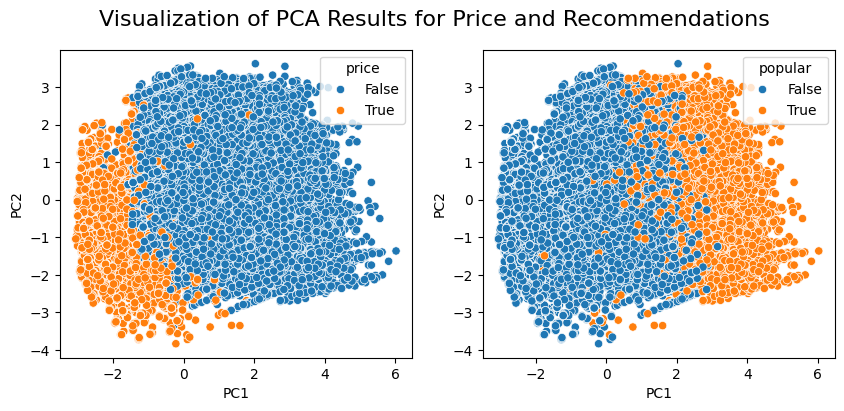

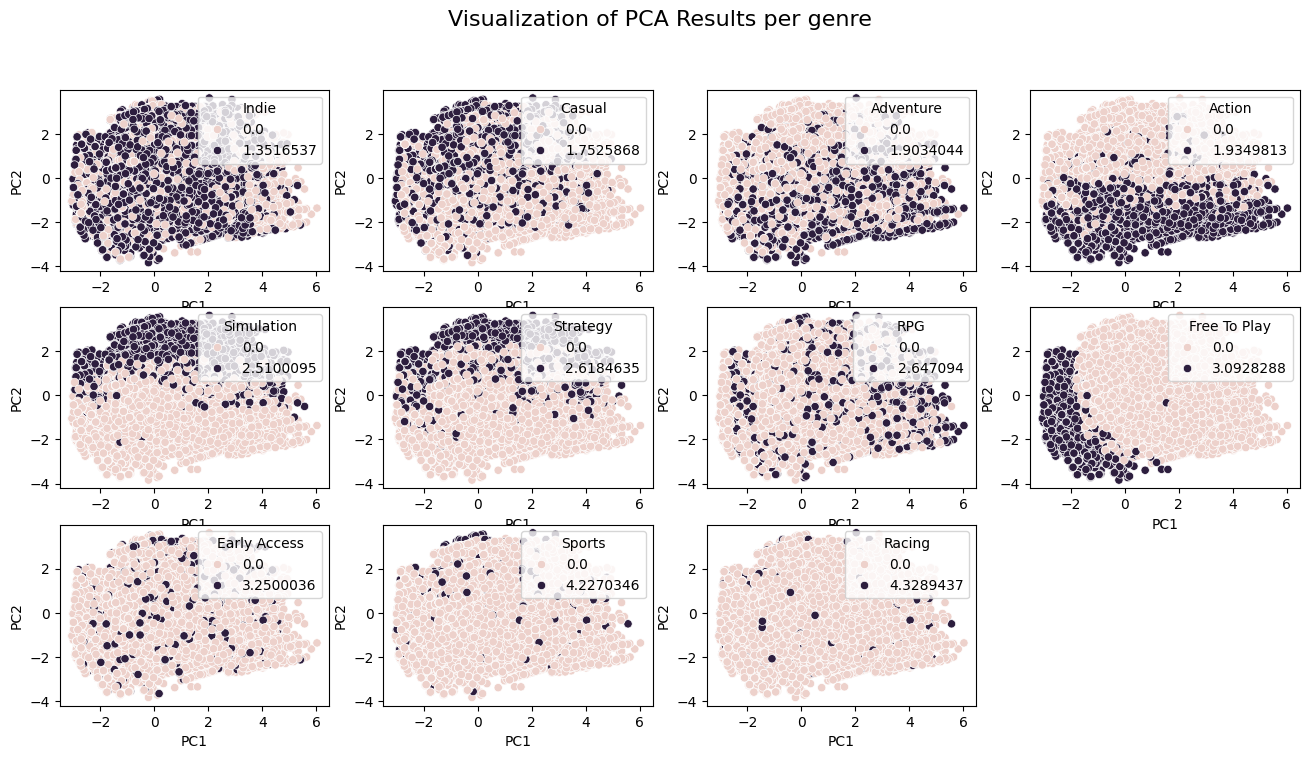

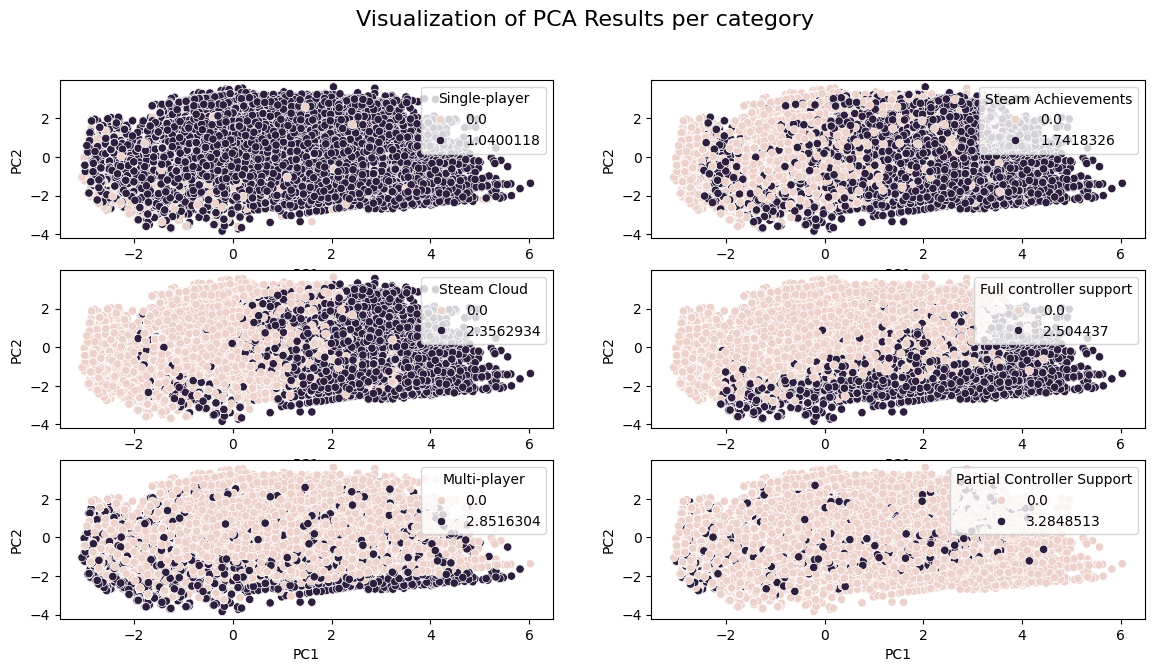

In [5]:
multiple_scatterplot(
    data=pc_df,
    title="Visualization of PCA Results for Price and Recommendations",
    x_col="PC1",
    y_col="PC2",
    n=1,
    m=2,
    hue_values=discrete_columns,
    xsize=10,
    ysize=4,
)
multiple_scatterplot(
    data=pc_df,
    title="Visualization of PCA Results per genre",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=4,
    hue_values=genres,
    xsize=16,
    ysize=8,
)
multiple_scatterplot(
    data=pc_df,
    title="Visualization of PCA Results per category",
    x_col="PC1",
    y_col="PC2",
    n=3,
    m=2,
    hue_values=categories,
    xsize=14,
    ysize=7,
)

# Test variance to define optimal Centroids

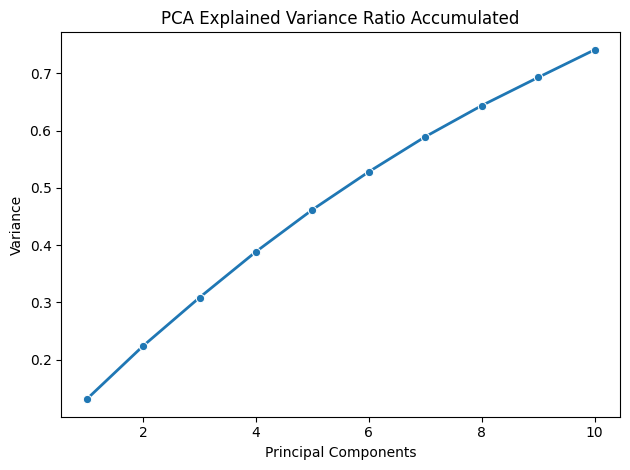

Total variance explained by PC1+PC2+PC3: 0.30852282
Variance explained by each Principal Component: [0.13096902 0.09305187 0.08450194 0.08002494 0.07327636 0.06621873
 0.06118968 0.05434614 0.04913573 0.04821097]


In [6]:
# Visualice accumulated variance ratio of principal components
make_plot(
    plot_type="line",
    data=None,
    x_col=np.arange(1, 11),
    y_col=pca.explained_variance_ratio_.cumsum(),
    title='PCA Explained Variance Ratio Accumulated',
    xlabel="Principal Components",
    ylabel="Variance",
)
plt.show()

print(
    "Total variance explained by PC1+PC2+PC3:", pca.explained_variance_ratio_[:3].sum()
)
print("Variance explained by each Principal Component:", pca.explained_variance_ratio_)

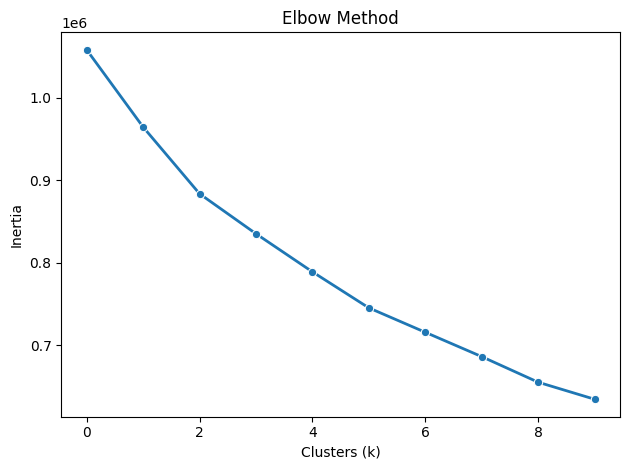

In [7]:
# Visualice elbow method on inertias
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(featured_data)
    inertias.append(km.inertia_)

make_plot(
    plot_type="line",
    data=inertias,
    x_col=None,
    y_col=None,
    title='Elbow Method',
    xlabel="Clusters (k)",
    ylabel="Inertia",
    xticks=k_range,
)
plt.show()

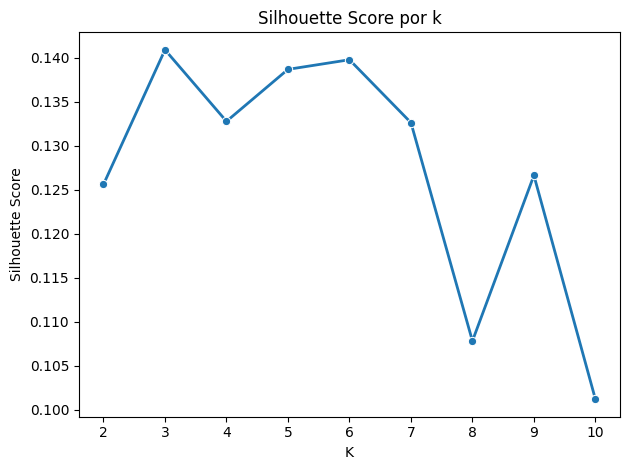

In [ ]:
# Visualice Silhouette Score
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(featured_data)
    sil_scores.append(silhouette_score(featured_data, labels))

make_plot(
    plot_type="line",
    data=None,
    x_col=range(2, 11),
    y_col=sil_scores,
    title='Silhouette Score por k',
    xlabel="K",
    ylabel="Silhouette Score",
)
plt.show()

In [8]:
# See what features influence more on each principal component
loadings = pd.DataFrame(
    pca.components_.T[:, :3], columns=["PC1", "PC2", "PC3"], index=featured_data.columns
)
print(loadings["PC1"].abs().sort_values(ascending=False).head(5))
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))
print(loadings["PC2"].abs().sort_values(ascending=False).head(5))

price                      0.502221
Steam Cloud                0.440856
recommendations            0.405347
Free To Play               0.397360
Full controller support    0.331779
Name: PC1, dtype: float32
Simulation                 0.507544
Action                     0.439920
Full controller support    0.409995
Strategy                   0.390094
Free To Play               0.245732
Name: PC2, dtype: float32
Simulation                 0.507544
Action                     0.439920
Full controller support    0.409995
Strategy                   0.390094
Free To Play               0.245732
Name: PC2, dtype: float32


# Model Training

In [9]:
# Train a KMEANS model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(featured_data)
pc_df["labels"] = kmeans_labels
fig = px.scatter_3d(
    pc_df, x="PC1", y="PC2", z="PC3", color="labels", title="PCA 3D Visualization"
)
centroids_cords = pc_df.groupby("labels")[["PC1", "PC2", "PC3"]].mean().reset_index()

# Add centroids
fig.add_trace(
    go.Scatter3d(
        x=centroids_cords["PC1"],
        y=centroids_cords["PC2"],
        z=centroids_cords["PC3"],
        mode="markers+text",
        marker=dict(
            size=12, color="black", symbol="diamond", line=dict(color="white", width=2)
        ),
        text=centroids_cords["labels"],
        textposition="top center",
        name="Centroides",
    )
)
fig.show()
fig.write_html(TRAINING_OUTPUT_PLOTS_PATH)

In [43]:
# Analyce kmeans labels output
centroids = kmeans.cluster_centers_
df_centroids = pd.DataFrame(
    centroids,
    columns=featured_data.columns,
    index=[f"Cluster {i}" for i in range(kmeans.n_clusters)]
)
# See top 5 features
bool_features = [col for col in featured_data.columns if col not in ['price', 'popular']]

for i in range(kmeans.n_clusters):
    top_generos = df_centroids.loc[f"Cluster {i}", bool_features].sort_values(ascending=False).head(5)
    print(f"\n--- Cluster {i} ---")
    print(f"Mean price: {df_centroids.loc[f'Cluster {i}', 'price']:.2f}")
    print(f"Mean recommendations: {df_centroids.loc[f'Cluster {i}', 'recommendations']:.2f}")
    print("Top genres/categories:")
    print(top_generos)



--- Cluster 0 ---
Mean price: -0.14
Mean recommendations: -0.14
Top genres/categories:
Multi-player     1.979262
Early Access     1.554329
Action           1.045579
Indie            0.915168
Single-player    0.831040
Name: Cluster 0, dtype: float32

--- Cluster 1 ---
Mean price: 0.57
Mean recommendations: 0.69
Top genres/categories:
Steam Cloud                2.131586
Steam Achievements         1.510546
Full controller support    1.101627
Single-player              1.032892
Indie                      0.965337
Name: Cluster 1, dtype: float32

--- Cluster 2 ---
Mean price: -0.21
Mean recommendations: -0.27
Top genres/categories:
Single-player    1.039314
Indie            0.956098
Casual           0.873798
Adventure        0.808380
Action           0.673555
Name: Cluster 2, dtype: float32
